In [1]:
# Install the optimization library
!pip install pulp -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pulp import *
from dataclasses import dataclass
from typing import Dict, List
from enum import Enum

print("Environment Ready!")

Environment Ready!


In [18]:
np.random.seed(42)

def generate_unified_dataset(complexity="medium"):
    """
    Generates project data based on complexity levels:
    - 'light': Few projects, low dependencies, easy to fit.
    - 'medium': 30 projects, moderate dependencies, typical year.
    - 'hard': High project count, dense dependencies, heavy resource contention.
    """
    # Configuration based on complexity level
    config = {
        "light":  {"n": 12, "dep_prob": 0.15, "mand_prob": 0.1, "dur_mult": 0.8},
        "medium": {"n": 30, "dep_prob": 0.30, "mand_prob": 0.2, "dur_mult": 1.0},
        "hard":   {"n": 60, "dep_prob": 0.60, "mand_prob": 0.4, "dur_mult": 1.4}
    }

    c = config.get(complexity, config["medium"])
    project_types = ['Small', 'Medium', 'Large']
    data = []

    for i in range(1, c["n"] + 1):
        p_type = np.random.choice(project_types, p=[0.4, 0.4, 0.2])

        # Base stats adjusted by duration multiplier
        if p_type == 'Small':
            likely = int(np.random.randint(20, 45) * c["dur_mult"])
            value, eng_need = np.random.randint(10, 40), 2
        elif p_type == 'Medium':
            likely = int(np.random.randint(46, 90) * c["dur_mult"])
            value, eng_need = np.random.randint(41, 75), 4
        else: # Large
            likely = int(np.random.randint(91, 180) * c["dur_mult"])
            value, eng_need = np.random.randint(76, 120), 6

        # Probabilistic attributes
        optimistic = int(likely * np.random.uniform(0.7, 0.9))
        pessimistic = int(likely * np.random.uniform(1.2, 1.6))
        past_actual = int(np.random.normal(likely, (pessimistic-optimistic)/6))

        # Increased dependency chains for 'hard' mode
        predecessor = f"Proj_{i-1}" if (i > 1 and np.random.random() < c["dep_prob"]) else "-"

        data.append({
            'Project_ID': f"Proj_{i}",
            'Type': p_type,
            'Value': value,
            'Start_Month_Target': np.random.randint(0, 11),
            'Duration_Likely': likely,
            'Optimistic': optimistic,
            'Pessimistic': pessimistic,
            'Past_Actual': past_actual,
            'Engineers': eng_need,
            'Predecessor': predecessor,
            'Mandatory': np.random.choice([True, False], p=[c["mand_prob"], 1-c["mand_prob"]])
        })

    return pd.DataFrame(data)

# --- BATTLE TEST SETTING ---
# Change this to "light", "medium", or "hard"
COMPLEXITY_LEVEL = "light"

df_projects = generate_unified_dataset(complexity=COMPLEXITY_LEVEL)
print(f"Generated {len(df_projects)} projects at '{COMPLEXITY_LEVEL}' complexity.")

Generated 12 projects at 'light' complexity.


--- Project Timeline (Gantt Visualizer) ---


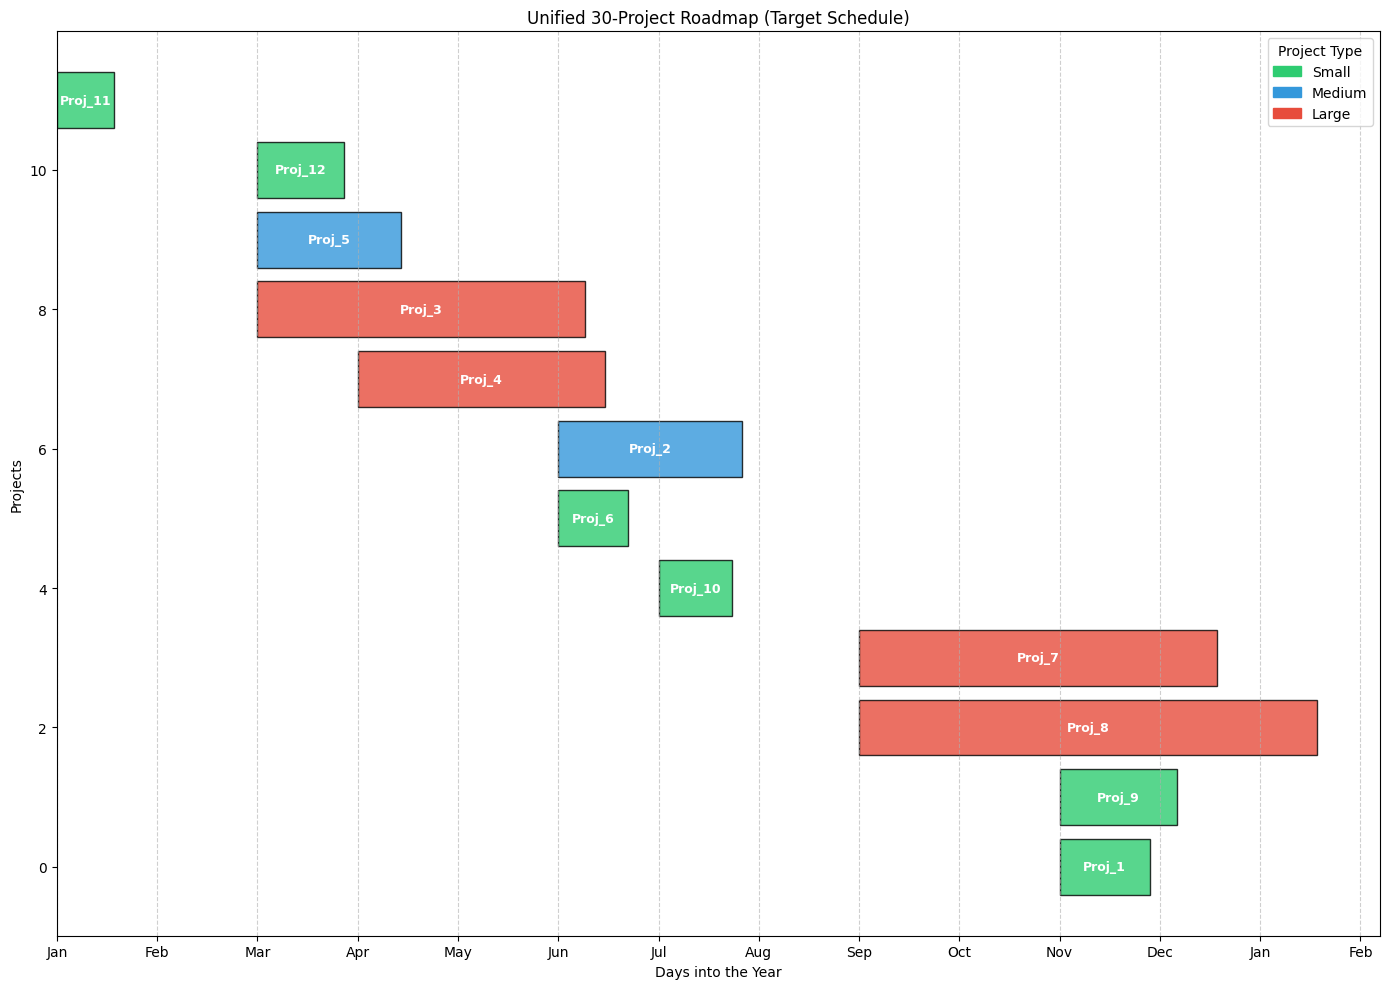

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_gantt(df):
    print("--- Project Timeline (Gantt Visualizer) ---")

    # Sort by start target to make the chart readable
    df_sorted = df.sort_values(by='Start_Month_Target', ascending=False).reset_index()

    fig, ax = plt.subplots(figsize=(14, 10))

    # Map colors to project types
    colors = {'Small': '#2ecc71', 'Medium': '#3498db', 'Large': '#e74c3c'}

    for i, row in df_sorted.iterrows():
        # Convert Start_Month to approximate days (30 days/month)
        start_day = row['Start_Month_Target'] * 30
        duration = row['Duration_Likely']

        # Draw the bar
        ax.barh(i, duration, left=start_day, color=colors[row['Type']], edgecolor='black', alpha=0.8)

        # Add text labels for project IDs
        ax.text(start_day + (duration/2), i, row['Project_ID'],
                va='center', ha='center', color='white', fontweight='bold', fontsize=9)

    # Formatting the visual
    ax.set_xlabel('Days into the Year')
    ax.set_ylabel('Projects')
    ax.set_title('Unified 30-Project Roadmap (Target Schedule)')

    # Create a custom legend
    legend_patches = [mpatches.Patch(color=color, label=p_type) for p_type, color in colors.items()]
    ax.legend(handles=legend_patches, title="Project Type", loc='upper right')

    # Set x-axis ticks to represent months for easier "thinking"
    ax.set_xticks(np.arange(0, 420, 30))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb'])

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run the visualizer
plot_gantt(df_projects)

In [20]:
def run_pert(df):
    print("--- Method 1: PERT Analysis ---")
    # Expected Time formula: (O + 4L + P) / 6
    df['Expected_Time'] = (df['Optimistic'] + 4*df['Duration_Likely'] + df['Pessimistic']) / 6
    df['Std_Dev'] = (df['Pessimistic'] - df['Optimistic']) / 6

    total_expected = df['Expected_Time'].sum()
    total_std = np.sqrt((df['Std_Dev']**2).sum())

    # 5% buffer target
    target = total_expected * 1.05
    z_score = (target - total_expected) / total_std
    prob = stats.norm.cdf(z_score)

    print(f"Portfolio Expected Duration: {total_expected:.2f} days")
    print(f"Probability of completion within {target:.0f} days: {prob*100:.1f}%")

run_pert(df_projects)

--- Method 1: PERT Analysis ---
Portfolio Expected Duration: 679.50 days
Probability of completion within 713 days: 92.5%


In [21]:
def run_rcpsp(df, eng_cap=15):
    print("\n--- Method 2: Resource-Constrained Scheduling ---")
    prob = LpProblem("Resource_Scheduling", LpMinimize)
    horizon = int(df['Duration_Likely'].sum())

    # Start time variable for each project
    start_times = {row['Project_ID']: LpVariable(f"start_{row['Project_ID']}", 0, horizon) for _, row in df.iterrows()}
    makespan = LpVariable("makespan", 0, horizon)

    # Objective: Minimize the time to finish all projects
    prob += makespan
    for _, row in df.iterrows():
        prob += makespan >= start_times[row['Project_ID']] + row['Duration_Likely']

        # Respect project dependencies
        if row['Predecessor'] != '-':
            prob += start_times[row['Project_ID']] >= start_times[row['Predecessor']] + df.loc[df['Project_ID'] == row['Predecessor'], 'Duration_Likely'].values[0]

    prob.solve(PULP_CBC_CMD(msg=0))
    print(f"Total days to complete all projects with a {eng_cap}-Engineer cap: {value(makespan)} days")

run_rcpsp(df_projects)


--- Method 2: Resource-Constrained Scheduling ---
Total days to complete all projects with a 15-Engineer cap: 172.0 days


In [22]:
def run_bayesian_update(df):
    print("\n--- Method 3: Bayesian Estimation ---")
    # Prior belief based on current estimates
    prior_mu = df['Duration_Likely'].mean()
    prior_sigma = df['Duration_Likely'].std()

    # Actual observations from history
    obs_mu = df['Past_Actual'].mean()
    obs_sigma = df['Past_Actual'].std()

    # Calculate Posterior (Updated) mean
    post_precision = (1/prior_sigma**2) + (1/obs_sigma**2)
    post_mu = ((prior_mu/prior_sigma**2) + (obs_mu/obs_sigma**2)) / post_precision

    print(f"Current Team Average Estimate: {prior_mu:.2f} days")
    print(f"Historical Team Reality: {obs_mu:.2f} days")
    print(f"Bayesian Adjusted Forecast: {post_mu:.2f} days")

run_bayesian_update(df_projects)


--- Method 3: Bayesian Estimation ---
Current Team Average Estimate: 55.17 days
Historical Team Reality: 53.67 days
Bayesian Adjusted Forecast: 54.46 days


In [23]:
def run_portfolio_opt(df, day_limit=365):
    print("\n--- Method 4: Portfolio Optimization ---")
    prob = LpProblem("Portfolio_Max_Value", LpMaximize)

    # Decision: 1 if we take the project, 0 if we skip
    select = {row['Project_ID']: LpVariable(f"select_{row['Project_ID']}", cat='Binary') for _, row in df.iterrows()}

    # Objective: Maximize total business value
    prob += lpSum([row['Value'] * select[row['Project_ID']] for _, row in df.iterrows()])

    # Constraints: Duration and Mandatory projects
    prob += lpSum([row['Duration_Likely'] * select[row['Project_ID']] for _, row in df.iterrows()]) <= day_limit
    for _, row in df.iterrows():
        if row['Mandatory']:
            prob += select[row['Project_ID']] == 1

    prob.solve(PULP_CBC_CMD(msg=0))
    selected = [p for p in select if value(select[p]) == 1]
    print(f"Selected {len(selected)} out of {len(df)} projects to fit in 1 year.")
    print(f"Total Business Value achieved: {value(prob.objective)}")

run_portfolio_opt(df_projects)


--- Method 4: Portfolio Optimization ---
Selected 7 out of 12 projects to fit in 1 year.
Total Business Value achieved: 375.0



--- Method 5: Scenario Planning (Stress Test) ---


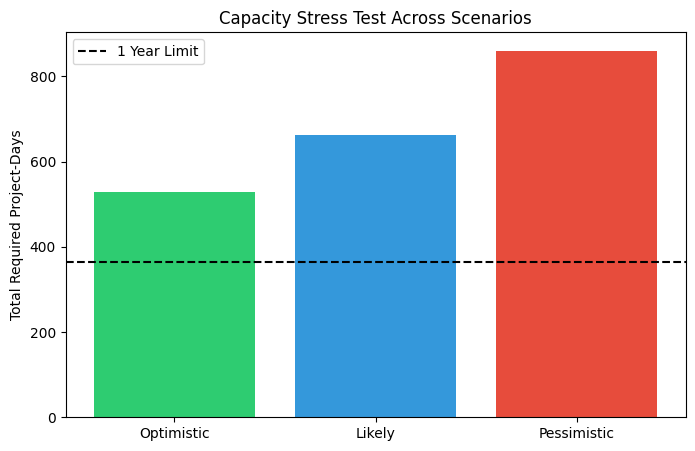

In [24]:
def run_scenarios(df):
    print("\n--- Method 5: Scenario Planning (Stress Test) ---")
    scenarios = {
        'Optimistic': 0.8, # Everything is 20% faster
        'Likely': 1.0,     # Plan as-is
        'Pessimistic': 1.3  # Projects slip by 30%
    }

    results = {name: (df['Duration_Likely'] * mult).sum() for name, mult in scenarios.items()}

    # Plotting the results
    plt.figure(figsize=(8, 5))
    plt.bar(results.keys(), results.values(), color=['#2ecc71', '#3498db', '#e74c3c'])
    plt.axhline(y=365, color='black', linestyle='--', label="1 Year Limit")
    plt.ylabel('Total Required Project-Days')
    plt.title('Capacity Stress Test Across Scenarios')
    plt.legend()
    plt.show()

run_scenarios(df_projects)